In [186]:
import importlib
import NeuralNetwork

importlib.reload(NeuralNetwork)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np

In [187]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"CUDA is available. Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA not available. Using CPU.")

CUDA not available. Using CPU.


In [188]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [189]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
print(f"train size: {train_size}, val size: {val_size}, test size: {len(test_dataset)}")

train size: 192000, val size: 48000, test size: 40000


In [190]:
# Create a DataLoader for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [191]:
# Create model and train
model = NeuralNetwork(hidden_sizes=[512, 256, 128], device=device)

In [192]:
model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=10)

Epoch 10/10: 100%|██████████| 3750/3750 [01:06<00:00, 56.75it/s] 


,train_loss,val_loss,val_acc
epoch,,,
1,0.337040,0.201121,0.946646
2,0.278414,0.150076,0.961708
3,0.261251,0.120848,0.967271
4,0.249862,0.180213,0.949646
5,0.248506,0.146709,0.961875
6,0.242315,0.154148,0.958875
7,0.240762,0.143580,0.961458
8,0.237792,0.163233,0.957917
9,0.240682,0.139406,0.964958


In [193]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)
test_acc = model.accuracy(test_loader)

100%|██████████| 625/625 [00:10<00:00, 59.24it/s]


In [194]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%, Test: {(test_acc*100):.2f}%")

Train: 96.37%, Validation: 96.19%, Test: 96.30%


In [196]:
preds = model.predict(test_loader).cpu()

y_true = []
for _, y_batch in test_loader:
    y_true.append(y_batch)
y_true = torch.cat(y_true)

100%|██████████| 625/625 [00:09<00:00, 65.10it/s]


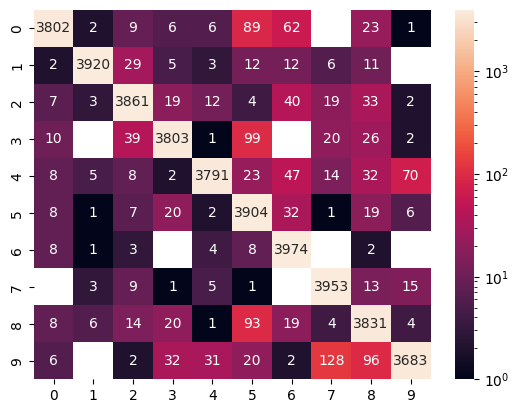

In [197]:
from matplotlib.colors import LogNorm

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, norm=LogNorm(), annot=True, fmt='d')
plt.show()

## Prune Neurons and Retrain

In [198]:
model.prune_hidden_neurons(train_loader,prune_rate=0.2)

In [199]:
model.train_model(train_loader, val_loader, epochs=5)

Epoch 5/5: 100%|██████████| 3750/3750 [01:09<00:00, 54.29it/s] 


,train_loss,val_loss,val_acc
epoch,,,
1,0.225058,0.120320,0.967542
2,0.220685,0.135477,0.961979
3,0.218762,0.182468,0.955438
4,0.224467,0.131990,0.964792
5,0.219557,0.138330,0.964938


In [200]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)
test_acc = model.accuracy(test_loader)

100%|██████████| 625/625 [00:09<00:00, 67.63it/s]


In [201]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%, Test: {(test_acc*100):.2f}%")

Train: 96.78%, Validation: 96.49%, Test: 96.57%
